### Single Linear Layer for **multi-class classification** using PyTorch

We will build the *simplest* possible classifier: **one** `nn.Linear` layer.


In order to build a deep learning pipeline we need to:

- Preprocess and load data
- Define model: Create a sequential model, specify the number of hidden layers in the neural network, their size and the input and output size.
- Choose loss and optimizer
- Fit model: This is the training step of the neural network.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)


### The problem we will solve: classify a person into **5 health risk categories**

We'll use **dummy (synthetic)** data with two features.


**Features** — the input(s) to our model (e.g., BMI and Blood Pressure).

****Label** — an integer class id in `{0,1,2,3,4}` (5 classes).


#### Load the dataset from a CSV file

We'll load a small synthetic dataset from `health_multiclass.csv` with:
- **2 features** per example
- **5 classes** (labels `0..4`)

**Use case idea:** a simple triage/risk scoring toy example where the model predicts one of:
`Healthy`, `At-Risk`, `Needs Checkup`, `Chronic`, `Critical`.


Loaded: /content/drive/MyDrive/health_multiclass.csv
X shape: torch.Size([600, 2])
y shape: torch.Size([600])


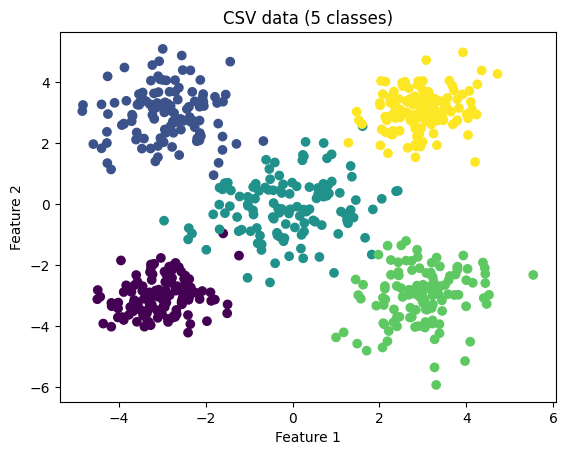

In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

# --- Load data from CSV ---
# CSV columns: feature1, feature2, label (0..4)
csv_path = '/content/drive/MyDrive/health_multiclass.csv'
df = pd.read_csv(csv_path)

X = torch.tensor(df[['feature1','feature2']].values, dtype=torch.float32)
y = torch.tensor(df['label'].values, dtype=torch.long)  # CrossEntropyLoss expects class indices (Long)

print('Loaded:', csv_path)
print('X shape:', X.shape)
print('y shape:', y.shape)

# Optional: human-readable class names
class_names = [
    'Healthy',
    'At-Risk',
    'Needs Checkup',
    'Chronic',
    'Critical'
]

# Visualize
plt.figure()
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy())
plt.title('CSV data (5 classes)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


#### Create the model

This network will require only **one layer with **5 output neurons** (one per class)**.


In [26]:
# Single linear layer (2 → 5 logits)
num_classes = 5
model = torch.nn.Linear(in_features=2, out_features=num_classes)


_Note:_ We keep the model as **only one** `nn.Linear` layer (a single linear layer (multinomial logistic regression)).


#### Create the loss function and optimizer


We will use:
- **MSE** (Mean Squared Error) as the loss
- **SGD** (Stochastic Gradient Descent) as the optimizer

Even though classification is often trained with other losses, we keep this notebook **very basic** as requested.


In [27]:
# Cross-entropy for multi-class classification
# (Pass raw logits to the loss; do NOT apply softmax before CrossEntropyLoss.)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


#### Train the model

We will:
1. Compute logits using the linear layer
2. Convert logits → probabilities with `sigmoid`
3. Compute MSE loss between probabilities and labels


**epochs** : number of training iterations


In [28]:
losses = []
accuracies = []
epochs = 300

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X)                 # (N, C)
    loss = loss_fn(logits, y)         # y is (N,) with class indices

    loss.backward()
    optimizer.step()

    # Track metrics
    with torch.no_grad():
        probs = torch.softmax(logits, dim=1)    # (N, C)
        preds = torch.argmax(probs, dim=1)      # (N,)
        acc = (preds == y).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

print('Finished training the model')
print('Final loss:', losses[-1])
print('Final accuracy:', accuracies[-1])


Finished training the model
Final loss: 0.15757521986961365
Final accuracy: 0.9733333587646484


#### Visualize the training


We will plot:
- Loss vs epoch
- Accuracy vs epoch


In [29]:
history = {"loss": losses, "accuracy": accuracies}
print(history.keys())


dict_keys(['loss', 'accuracy'])


Plots:


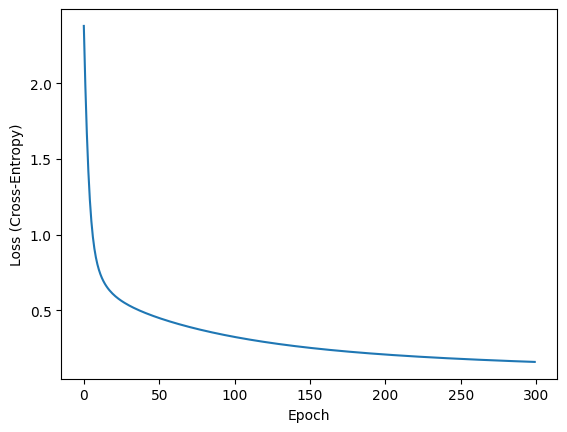

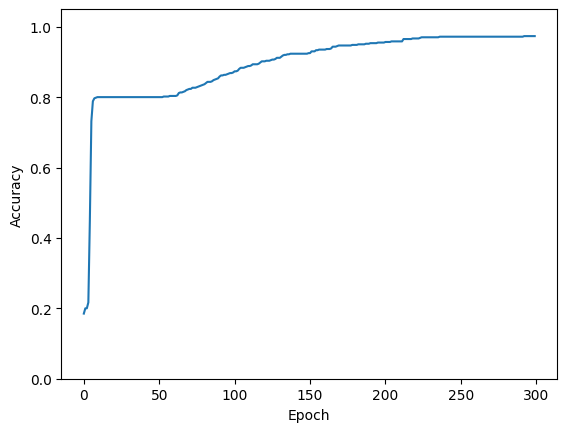

In [30]:
plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.plot(history['loss'])
plt.show()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(history['accuracy'])
plt.ylim(0, 1.05)
plt.show()


You should see the loss decreasing and the accuracy increasing as training progresses.


#### Visualize the learned decision boundary

Because we used **2 features**, we can draw the separating boundary learned by the single neuron.


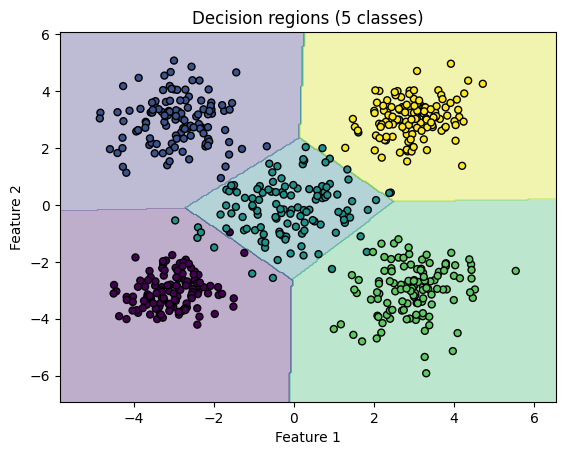

In [31]:
# Decision regions (multi-class)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 300),
    torch.linspace(y_min, y_max, 300),
    indexing='ij',
)
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

with torch.no_grad():
    grid_logits = model(grid)
    grid_preds = torch.argmax(torch.softmax(grid_logits, dim=1), dim=1)
    grid_preds = grid_preds.reshape(xx.shape)

plt.figure()
plt.contourf(xx.numpy(), yy.numpy(), grid_preds.numpy(), alpha=0.35)
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy(), edgecolor='k', s=25)
plt.title('Decision regions (5 classes)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


#### Test the model on a new sample


In [ ]:
x_new = torch.tensor([[1.0, 1.0]], dtype=torch.float32)

with torch.no_grad():
    logits = model(x_new)                 # (1, C)
    probs = torch.softmax(logits, dim=1)[0]  # (C,)
    pred_class = probs.argmax().item()

print("Class probabilities:", probs.tolist())
print("Predicted class:", int(pred_class))

Class probabilities: [0.006368167698383331, 0.03922687843441963, 0.6016198992729187, 0.03861621394753456, 0.31416887044906616]
Predicted class: 2


#### Show the final weights of the model


In [ ]:
w = model.weight.detach().cpu()
b = model.bias.detach().cpu()
print(f"weight = {w}")
print(f"bias   = {b}")


weight = tensor([[-0.8613, -0.7777],
        [-1.0135,  1.4302],
        [ 0.0648,  0.1983],
        [ 1.2049, -0.8590],
        [ 1.1042,  1.2839]])
bias   = tensor([-0.0783, -0.3160,  2.5679, -0.2609, -0.2067])


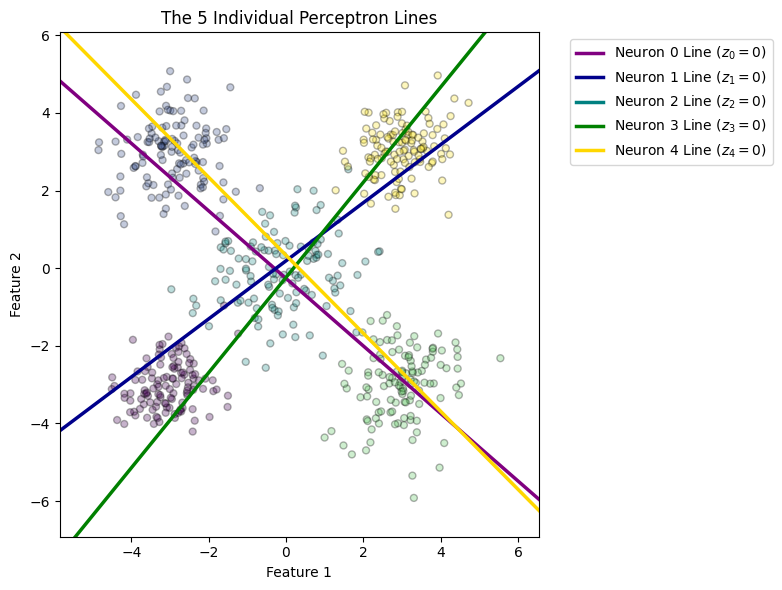

In [35]:
import numpy as np

# Extract weights and biases from the trained model
w = model.weight.detach().cpu().numpy()
b = model.bias.detach().cpu().numpy()

# Get the min and max limits for the plot
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

plt.figure(figsize=(8, 6))

# Plot the underlying data points as a reference
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy(), edgecolor='k', s=25, alpha=0.3)

# Create x values for drawing the lines
x_vals = np.linspace(x_min.item(), x_max.item(), 100)

# Colors matching the 5 classes
colors = ['purple', 'darkblue', 'teal', 'green', 'gold']

for i in range(num_classes):
    # The equation for the neuron is: w0*x + w1*y + b = 0
    # Solving for y (Feature 2) gives: y = (-w0*x - b) / w1

    # Avoid division by zero just in case w1 is extremely small
    if np.abs(w[i, 1]) > 1e-5:
        y_vals = (-w[i, 0] * x_vals - b[i]) / w[i, 1]
        plt.plot(x_vals, y_vals, label=f'Neuron {i} Line ($z_{i}=0$)', color=colors[i], linewidth=2.5)

# Restrict the view so lines don't zoom the plot way out
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title('The 5 Individual Perceptron Lines')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

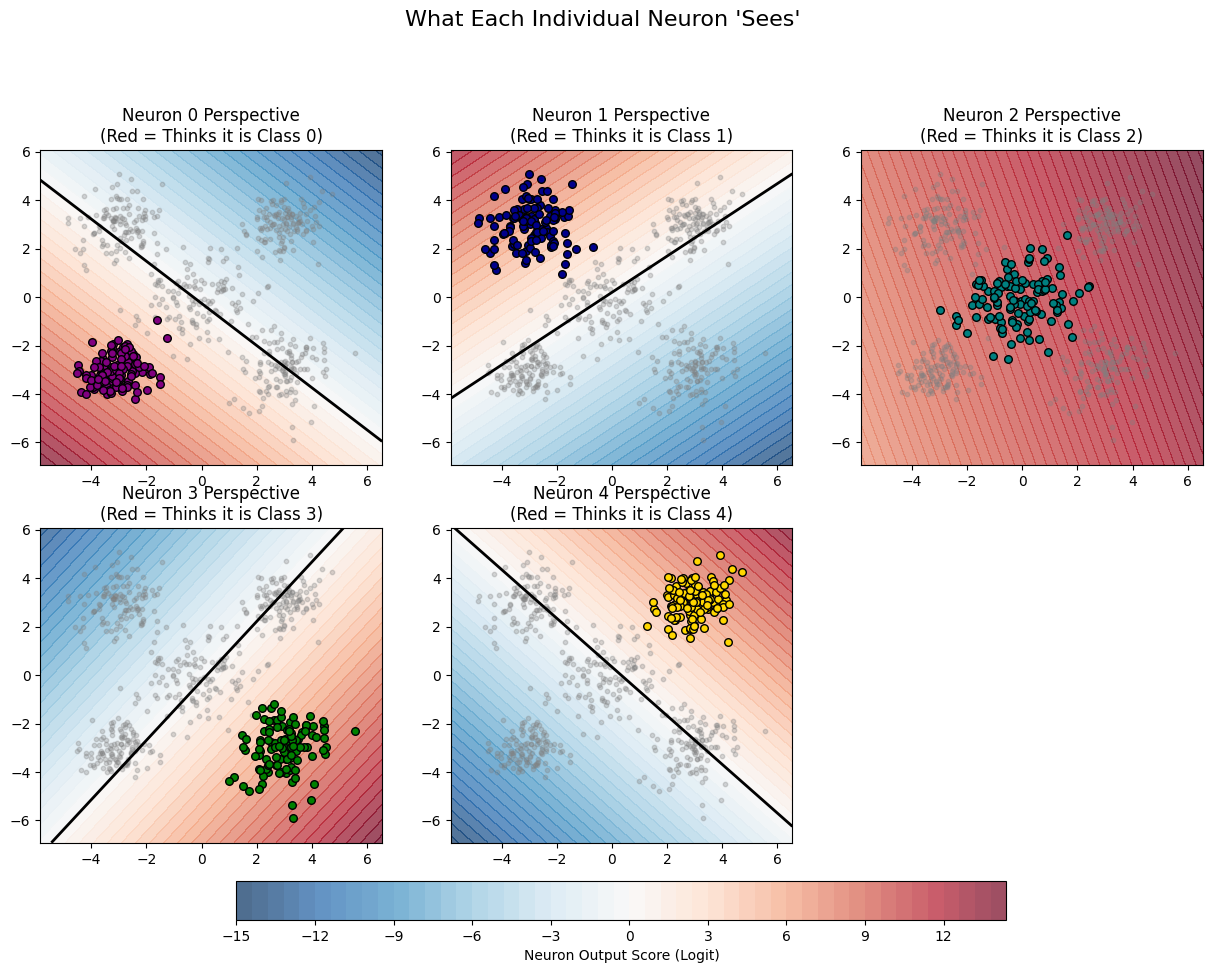

In [33]:
import numpy as np

# Create a grid of points to evaluate (same as the original notebook)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = torch.meshgrid(
    torch.linspace(x_min.item(), x_max.item(), 300),
    torch.linspace(y_min.item(), y_max.item(), 300),
    indexing='ij',
)
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

# Get the raw scores (logits) from the model for the whole grid
with torch.no_grad():
    grid_logits = model(grid)

# Set up a plot with 5 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['purple', 'darkblue', 'teal', 'green', 'gold']

for i in range(num_classes):
    ax = axes[i]

    # Get the scores for this specific neuron only
    z_i = grid_logits[:, i].reshape(xx.shape).numpy()

    # Plot the heat map (Red = positive score, Blue = negative score)
    vmax = np.abs(z_i).max()
    c = ax.contourf(xx.numpy(), yy.numpy(), z_i, levels=50, cmap='RdBu_r', vmin=-vmax, vmax=vmax, alpha=0.7)

    # Draw the zero-score line in black
    ax.contour(xx.numpy(), yy.numpy(), z_i, levels=[0], colors='black', linewidths=2)

    # Plot the data points: highlight this neuron's target class, gray out the rest
    is_class = (y.numpy() == i)
    ax.scatter(X[~is_class, 0].numpy(), X[~is_class, 1].numpy(), c='gray', s=10, alpha=0.3)
    ax.scatter(X[is_class, 0].numpy(), X[is_class, 1].numpy(), c=colors[i], edgecolor='k', s=30)

    ax.set_title(f'Neuron {i} Perspective\n(Red = Thinks it is Class {i})')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# Hide the 6th empty subplot
axes[5].axis('off')

# Add a colorbar to the figure to show the score scale
fig.colorbar(c, ax=axes.tolist(), orientation='horizontal', fraction=0.05, pad=0.05, label='Neuron Output Score (Logit)')

plt.suptitle("What Each Individual Neuron 'Sees'", fontsize=16, y=1.02)
plt.show()